## 1. Setup and Data Loading

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DRIVE_DATA_DIR = "/content/drive/MyDrive/OCT2017_MODIFIED"
LOCAL_DATA_DIR = "/content/OCT2017_MODIFIED"

if not os.path.exists(LOCAL_DATA_DIR):
    print("Copying dataset from Drive to local disk, this can take a few minutes...")
    os.system(f"cp -r '{DRIVE_DATA_DIR}' '{LOCAL_DATA_DIR}'")
    print("Copy complete.")
else:
    print("Local copy already exists, skipping copy.")

Local copy already exists, skipping copy.


In [ ]:
DATA_DIR = LOCAL_DATA_DIR
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]

print("Training image counts:")
for class_name in CLASS_NAMES:
    folder = os.path.join(TRAIN_DIR, class_name)
    print(f"  {class_name}: {len(os.listdir(folder))}")

print("\nTesting image counts:")
for class_name in CLASS_NAMES:
    folder = os.path.join(TEST_DIR, class_name)
    print(f"  {class_name}: {len(os.listdir(folder))}")

Training image counts:
  CNV: 1500
  DME: 1500
  DRUSEN: 1500
  NORMAL: 1500

Testing image counts:
  CNV: 250
  DME: 250
  DRUSEN: 250
  NORMAL: 250


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 6000 files belonging to 4 classes.
Using 4800 files for training.
Found 6000 files belonging to 4 classes.
Using 1200 files for validation.
Found 1000 files belonging to 4 classes.
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 2. Sample Images

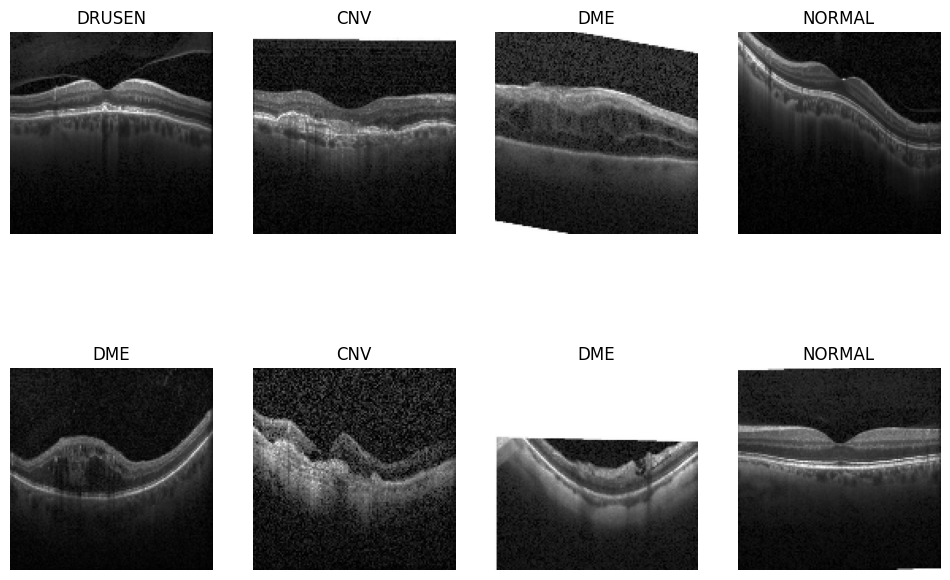

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
class_counts = {}
for i, class_name in enumerate(CLASS_NAMES):
    folder = os.path.join(TRAIN_DIR, class_name)
    class_counts[i] = len(os.listdir(folder))

total_images = sum(class_counts.values())
num_classes = len(CLASS_NAMES)

class_weight = {i: total_images / (num_classes * count) for i, count in class_counts.items()}
print("Class weights:", class_weight)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

head_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[head_early_stopping]
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.5483 - loss: 1.0588 - val_accuracy: 0.6300 - val_loss: 0.8783
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6469 - loss: 0.8646 - val_accuracy: 0.6275 - val_loss: 0.8804
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.6706 - loss: 0.8187 - val_accuracy: 0.6567 - val_loss: 0.8350
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.6952 - loss: 0.7667 - val_accuracy: 0.6650 - val_loss: 0.7904
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6950 - loss: 0.7606 - val_accuracy: 0.6642 - val_loss: 0.7948
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.7025 - loss: 0.7313 - val_accuracy: 0.6683 - val_loss: 0.7573
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7098 - loss: 0.7317 - val_accuracy: 0.6875 - val_loss: 0.7457
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.7281 - loss: 0.7024 - 

In [ ]:
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=[fine_tune_early_stopping]
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.5748 - loss: 1.2039 - val_accuracy: 0.6908 - val_loss: 0.8166
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.6558 - loss: 0.8996 - val_accuracy: 0.6858 - val_loss: 0.8294
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.6898 - loss: 0.8099 - val_accuracy: 0.6900 - val_loss: 0.8345
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.7119 - loss: 0.7479 - val_accuracy: 0.7025 - val_loss: 0.8281
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.7152 - loss: 0.7215 - val_accuracy: 0.7017 - val_loss: 0.8288
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7387 - loss: 0.6851 - val_accuracy: 0.7092 - val_loss: 0.8045
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7469 - loss: 0.6601 - val_accuracy: 0.7058 - val_loss: 0.7859
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.7573 - loss: 0.6290 - 

## 7. Final Evaluation

========== FINAL RESULTS ==========
Test Loss: 0.34917405247688293
Test Accuracy: 0.8759999871253967

              precision    recall  f1-score   support

         CNV       0.85      0.94      0.89       250
         DME       0.94      0.91      0.92       250
      DRUSEN       0.86      0.74      0.80       250
      NORMAL       0.86      0.92      0.89       250

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.87      1000
weighted avg       0.88      0.88      0.87      1000



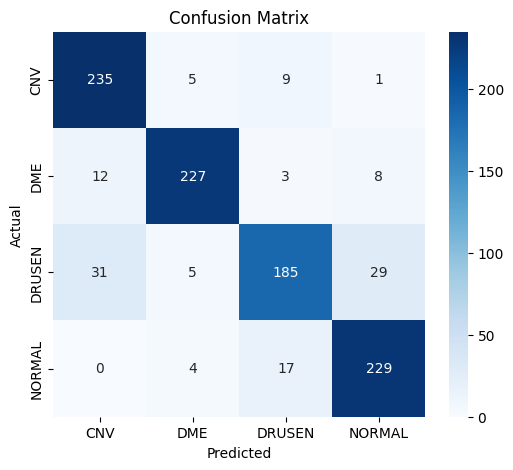

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("========== FINAL RESULTS ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 8. Save the Model

In [ ]:
model.save(os.path.join(DRIVE_DATA_DIR, "oct_classifier.keras"))
print("Saved model to Google Drive as oct_classifier.keras")

Saved model to Google Drive as oct_classifier.keras
